In [2]:
from instruments.spectrometer import Spectrometer
from instruments.spectrometer.utils import autoexposure

from instruments.monochromator.mono import MonochromatorControl
from instruments.filterwheel import FilterWheelControl

import matplotlib.pyplot as plt

In [2]:
sp = Spectrometer(serial="SR600410")

Connected to OCEANSR6 (SN SR600410)


In [3]:
filterwheel = FilterWheelControl('USB0::0x104D::0x1011::7A01020F12162064::RAW')

In [7]:
filterwheel.set_position(1)

In [11]:
mono = MonochromatorControl(port='COM4')
mono.initialize_arduino()
mono.home_motor()
mono.select_grating_mode(mode="VIS Grating")
mono.goto_lamp_baseline()

Connected to COM4; you can now initialize the Monochromator.
INFO: monochromator initialized; send `home` to start
INFO: homing
ADC: 283
OK: homed
OK: mode VIS
INFO: moving_steps 338
OK: moved 338


In [12]:
mono.set_wavelength(550.0)

INFO: moving 550.00
OK: wavelength 550.00


In [6]:
autoexposure(sp, target=0.8)

9374

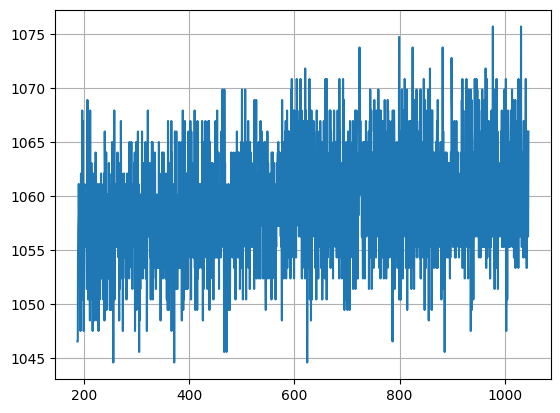

In [8]:
wl, counts = sp.snapshot()
plt.plot(wl, counts)
#plt.xlim([400, 1000])
#plt.ylim([0, 70000])
#plt.vlines(550, 0, 35000, 'r')
plt.grid()

In [8]:
mono.disconnect()
filterwheel.close()
sp.close()

NameError: name 'mono' is not defined